In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
CONDITIONS = ["ad", "ai"]
DATA = "preprocessed"
OUTPUT = "figures"

<class 'matplotlib.axes._axes.Axes'>


/tmp/ipykernel_16668/140417028.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


<class 'matplotlib.axes._axes.Axes'>


/tmp/ipykernel_16668/140417028.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


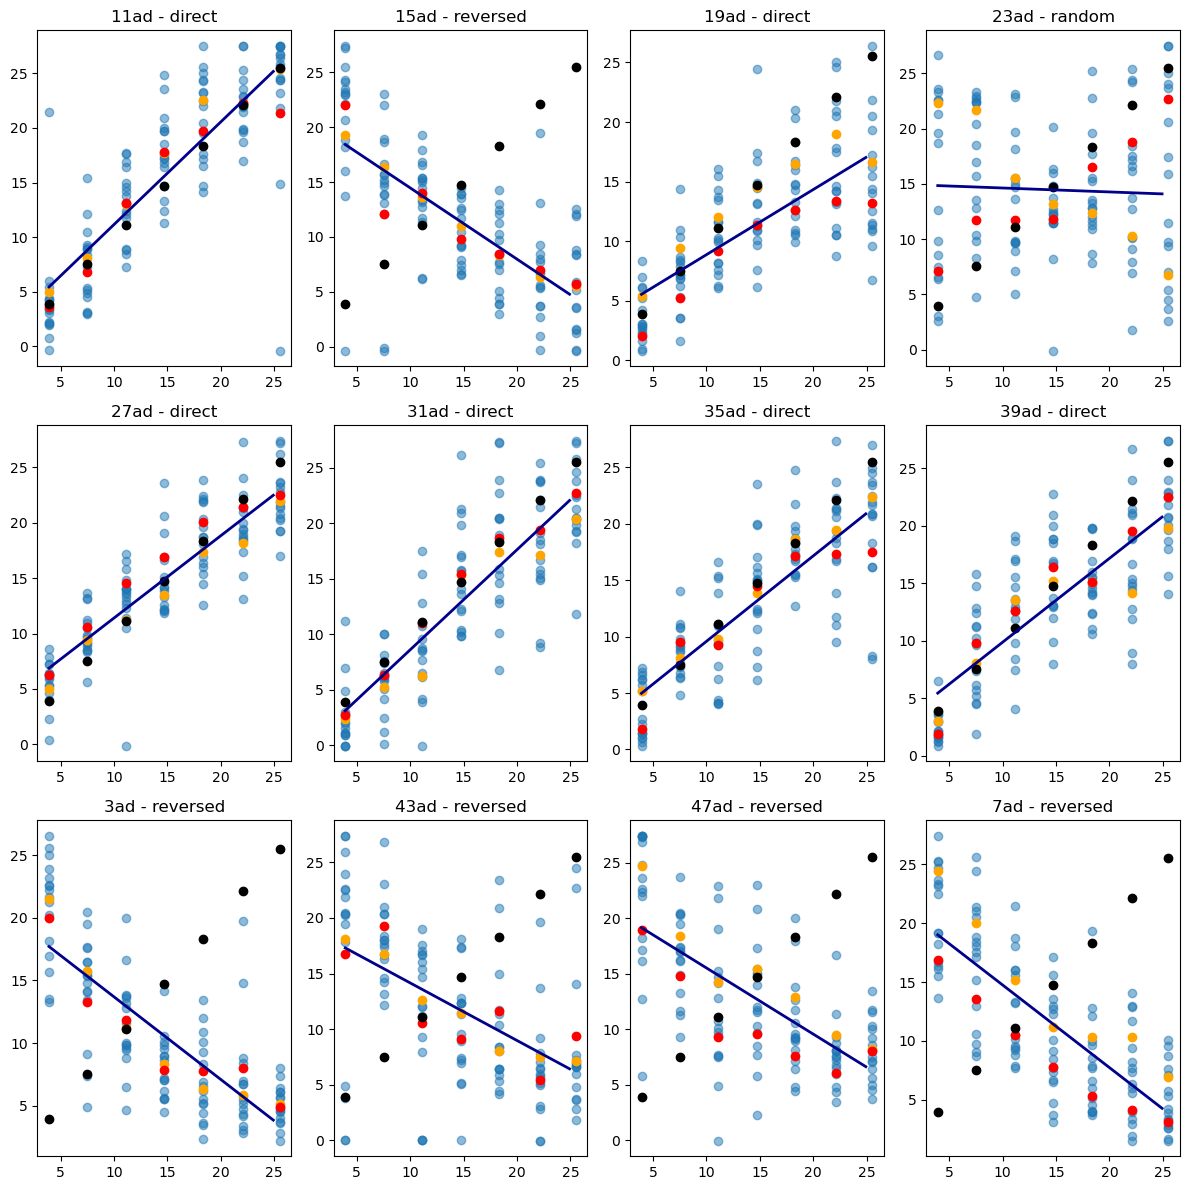

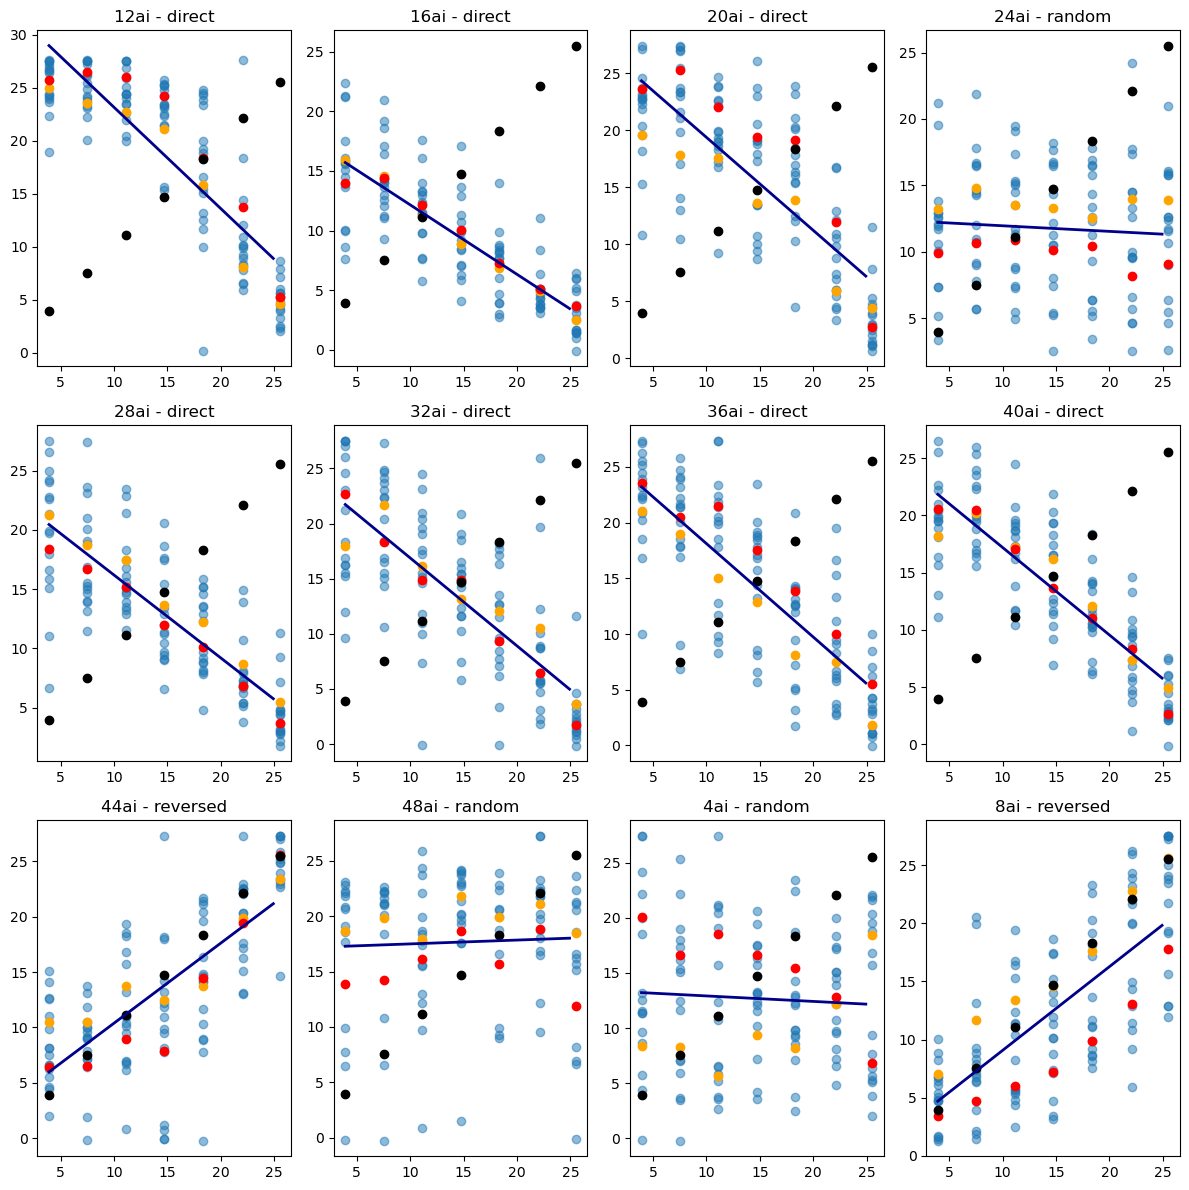

In [4]:
for condition in CONDITIONS:
    relevant = pd.read_csv(os.path.join(DATA, f"{condition}_relevant.csv"))
    blocks = pd.read_csv(os.path.join(DATA, f"{condition}_metrics.csv"))
    metrics = pd.read_csv(os.path.join(DATA, f"{condition}_participant_metrics.csv"))

    figure = plt.figure(figsize = (12,12))
    axs = figure.subplots(3,4).flatten()
    print(type(axs[0]))

    for iax, participant in enumerate(relevant.groupby(["participant_id"])):
        data = participant[1][participant[1]["phase"] == "Pre-Test"].sort_values(by=["target_pos_y"])

        unique_t = data["target_pos_y"].unique()

        ax = axs[iax]
        ax.scatter(data["target_pos_y"], data["current_pos_y"], alpha=0.5, zorder=0)
        ax.scatter(unique_t, unique_t, c="k", zorder = 2)

        
        mean_data = blocks[(blocks["phase"] == "Pre-Test") & (blocks["participant_id"] == participant[0][0])].sort_values(by=["target_pos_y"])
        ax.scatter(mean_data[mean_data["task"] == "avoiding"]["target_pos_y"], mean_data[mean_data["task"] == "avoiding"]["cursor_y_mean"], c="orange", zorder = 1)
        ax.scatter(mean_data[mean_data["task"] == "reaching"]["target_pos_y"], mean_data[mean_data["task"] == "reaching"]["cursor_y_mean"], c="red", zorder = 1)

        participant_metrics = metrics.loc[metrics["participant_id"] == participant[0][0]]

        theta_0 = participant_metrics["reg_slope"]
        theta_1 = participant_metrics["reg_intercept"]
        reg = lambda x: x * theta_0 + theta_1

        xx = np.arange(unique_t.min(), unique_t.max())
        ax.plot(xx, [reg(x) for x in xx], c="darkblue", linewidth=2)

        ax.set_title(participant[0][0] + " - " + participant_metrics["natural_mapping"].iloc[0])

    figure.tight_layout()
    figure.show()